# NHS England – Appointment & Capacity Analysis

**LSE Data Analytics Career Accelerator | DA201: Diagnostic Analysis using Python**

Analysed NHS appointment data from 2020–2022 using Python to assess demand, missed appointments, service utilisation and capacity patterns, translating findings into recommendations for workforce planning, appointment management and resource allocation.

# 1. Analytical Approach

### Analysis Roadmap

Three NHS datasets were imported and reviewed in Python: actual_duration.csv, appointments_regional.csv, and national_categories.xlsx. 

A structured roadmap to follow analytical process:

1.	Data ingestion
2.	Data wrangling
3.	Exploratory and descriptive analysis
4.	Explanatory visualisation
5.	Insights and recommendations


# 2. Data Preparation & Quality Checks

### Data Import & Setup

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Read the CSV and XLSX files.
ad = pd.read_csv('actual_duration.csv')
ar = pd.read_csv('appointments_regional.csv')
nc = pd.read_excel('national_categories.xlsx')

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv('actual_duration.csv')

# Determine shape of classlist.
print(ad.shape)

# View the DataFrame.
ad.head()

(137793, 8)


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,01-Dec-21,16-20 Minutes,730


In [3]:
# Determine whether there are missing values.
ad.isna().sum()

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

In [4]:
# To check duplicates:
print(ad.duplicated().sum())

0


In [5]:
# Determine the metadata of the data set.
ad.dtypes

sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object

In [6]:
# Determine the descriptive statistics of the data set.
ad.describe()

,count_of_appointments
count,137793.000000
mean,1219.080011
std,1546.902956
min,1.000000
25%,194.000000
50%,696.000000
75%,1621.000000
max,15400.000000


In [7]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv')

# Determine shape of classlist.
print(ar.shape)

# View the DataFrame.
ar.head()

(596821, 7)


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [8]:
# Determine whether there are missing values.
ar.isna().sum()

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

In [9]:
# To check duplicates:
print(ar.duplicated().sum())

21604


In [10]:
# Determine the metadata of the data set.
ar.dtypes

icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object

In [11]:
# Determine the descriptive statistics of the data set.
ar.describe()

,count_of_appointments
count,596821.000000
mean,1244.601857
std,5856.887042
min,1.000000
25%,7.000000
50%,47.000000
75%,308.000000
max,211265.000000


In [12]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel('national_categories.xlsx')

# Determine shape of classlist.
print(nc.shape)

# View the DataFrame.
nc.head()

(817394, 8)


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [13]:
# Determine whether there are missing values.
nc.isna().sum()

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

In [14]:
# Determine the metadata of the data set.
nc.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object

In [15]:
# To check duplicates:
print(nc.duplicated().sum())

0


In [16]:
# Determine the descriptive statistics of the data set.
nc.describe()

,appointment_date,count_of_appointments
count,817394,817394.000000
mean,2022-01-16 00:50:35.860796160,362.183684
min,2021-08-01 00:00:00,1.000000
25%,2021-10-25 00:00:00,7.000000
50%,2022-01-18 00:00:00,25.000000
75%,2022-04-07 00:00:00,128.000000
max,2022-06-30 00:00:00,16590.000000
std,NaN,1084.576600


**<h3>1. Actual Duration Dataset (actual_duration.csv)</h3>**


Dataset contained 137,793 rows and 8 columns, providing information on appointment durations across NHS regions and healthcare locations.

Key findings:
- No missing values were identified across any variables and no duplicate records were detected
- Most variables were categorical (object type), while count_of_appointments was correctly stored as an integer variable
Descriptive statistics showed considerable variation in appointment volumes:
* Mean appointment count: 1,219 appointments,
* Median: 696 appointments,
* Maximum recorded value: 15,400 appointments.
The substantial difference between the mean and maximum values suggests the presence of highly active locations or periods with unusually high appointment volumes. 

**<h3>2. Regional Appointments Dataset (appointments_regional.csv)</h3>**
Dataset contained 596,821 rows and 7 columns, covering appointment activity by healthcare professional type, appointment mode, booking intervals, and attendance status.

Key findings:
* No missing values were identified across the dataset.
* Approximately 21,604 duplicate records were detected, indicating potential repeated entries or replicated reporting across regions.

Descriptive statistics revealed a highly skewed distribution:
* Mean appointment count:  1,245 appointments,
* Median: only 47 appointments,
* Maximum value: over 211,000 appointments.
This large gap between the median and maximum values indicates the presence of significant outliers and highly concentrated appointment activity in certain categories or time periods. The distribution suggests that a relatively small number of appointment categories accounted for a disproportionately large share of total NHS activity.

**<h3>3. National Categories Dataset (national_categories.xlsx)</h3>**
Dataset contained 817,394 rows and 8 columns, making it the largest dataset used in the analysis. 
It provided detailed information on service settings, national consultation categories, and appointment activity.
Key findings: no missing values or duplicate records were identified.

Descriptive statistics indicated a highly skewed distribution:
* Mean appointment count: 362 appointments,
* Median: 25 appointments,
* Maximum value: 16,590 appointments.
The relatively low median compared with the maximum value suggests that most service categories operated at comparatively small volumes, while a limited number of service settings accounted for significantly larger appointment activity.


### Exploratory Data Analysis

**Question 1:** How many locations are there in the data set?

In [17]:
# Determine the number of locations across all datasets.
pd.concat([
    ad['icb_ons_code'],
    ar['icb_ons_code'],
    nc['icb_ons_code']
]).nunique()

42

In [18]:
# Unique locations as an alphabetical list.
sorted(ar['icb_ons_code'].unique())

['E54000008',
 'E54000010',
 'E54000011',
 'E54000013',
 'E54000015',
 'E54000018',
 'E54000019',
 'E54000022',
 'E54000023',
 'E54000024',
 'E54000025',
 'E54000026',
 'E54000027',
 'E54000028',
 'E54000029',
 'E54000030',
 'E54000031',
 'E54000032',
 'E54000034',
 'E54000036',
 'E54000037',
 'E54000038',
 'E54000039',
 'E54000040',
 'E54000041',
 'E54000042',
 'E54000043',
 'E54000044',
 'E54000048',
 'E54000050',
 'E54000051',
 'E54000052',
 'E54000053',
 'E54000054',
 'E54000055',
 'E54000056',
 'E54000057',
 'E54000058',
 'E54000059',
 'E54000060',
 'E54000061',
 'E54000062']

**Question 2:** What are the five locations with the highest number of appointments?



In [19]:
# Determine the top five locations based on record count.
top_5 = ad.groupby(['sub_icb_location_name', 'sub_icb_location_ons_code'])['count_of_appointments'] \
.sum() \
.sort_values(ascending=False) \
.head(5) \
.reset_index()

top_5

,sub_icb_location_name,sub_icb_location_ons_code,count_of_appointments
0,NHS North West London ICB - W2U3Z,E38000256,6976986
1,NHS North East London ICB - A3A8R,E38000255,5341883
2,NHS Kent and Medway ICB - 91Q,E38000237,5209641
3,NHS Hampshire and Isle Of Wight ICB - D9Y0V,E38000253,4712737
4,NHS South East London ICB - 72Q,E38000244,4360079


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [20]:
# Determine the number of service settings.
nc['service_setting'].nunique()


5

In [21]:
sorted(nc['service_setting'].unique())

['Extended Access Provision',
 'General Practice',
 'Other',
 'Primary Care Network',
 'Unmapped']

In [22]:
# Determine the number of service settings.
nc['service_setting'].nunique()

5

In [23]:
# Determine the number of context types.
nc['context_type'].nunique()

3

In [24]:
sorted(nc['context_type'].unique())

['Care Related Encounter', 'Inconsistent Mapping', 'Unmapped']

In [25]:
# Determine the number of national categories.
nc['national_category'].nunique()

18

In [26]:
sorted(nc['national_category'].unique())

['Care Home Needs Assessment & Personalised Care and Support Planning',
 'Care Home Visit',
 'Clinical Triage',
 'General Consultation Acute',
 'General Consultation Routine',
 'Group Consultation and Group Education',
 'Home Visit',
 'Inconsistent Mapping',
 'Non-contractual chargeable work',
 'Patient contact during Care Home Round',
 'Planned Clinical Procedure',
 'Planned Clinics',
 'Service provided by organisation external to the practice',
 'Social Prescribing Service',
 'Structured Medication Review',
 'Unmapped',
 'Unplanned Clinical Activity',
 'Walk-in']

In [27]:
# Determine the number of appointment status.
ar['appointment_status'].nunique()

3

In [28]:
sorted(ar['appointment_status'].unique())

['Attended', 'DNA', 'Unknown']

**<h3>Locations and Regional Coverage</h3>**
The analysis identified 42 unique NHS locations across the combined datasets. 

The five locations with the highest appointment volumes were:

- NHS North West London ICB – approximately 6.98 million appointments
- NHS North East London ICB – approximately 5.34 million appointments
- NHS Kent and Medway ICB – approximately 5.21 million appointments
- NHS Hampshire and Isle of Wight ICB – approximately 4.71 million appointments
- NHS South East London ICB – approximately 4.36 million appointments

Appointment activity was heavily concentrated within large urban regions, particularly London-based Integrated Care Boards (ICBs), likely reflecting higher population density, greater healthcare utilisation, and increased operational demand.
    
**<h3>Service Settings and Operational Categories</h3>**
The analysis identified 5 service settings, with General Practice representing the dominant operational setting within NHS primary care delivery.
The dataset also included:
- 3 context types,
- 18 national service categories,
- 3 appointment status categories (Attended, DNA, and Unknown)

The largest national categories were:
General Consultation Routine
General Consultation Acute
Clinical Triage
These findings suggest that NHS activity was primarily concentrated around routine and acute consultations, while specialised and support services accounted for a smaller share of total activity.

# 3. Exploratory Analysis – Demand & Appointment Patterns

### Appointment Demand & Timing Analysis

**Question 1:** Between what dates were appointments scheduled? 

In [29]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
ad['appointment_date'].head()

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object

In [30]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
nc['appointment_date'].head()

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]

In [31]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DateFrame.
ad['appointment_date']

0        2021-12-01
1        2021-12-01
2        2021-12-01
3        2021-12-01
4        2021-12-01
            ...    
137788   2022-06-30
137789   2022-06-30
137790   2022-06-30
137791   2022-06-30
137792   2022-06-30
Name: appointment_date, Length: 137793, dtype: datetime64[ns]

In [32]:
# Change the date format of ar['appointment_date'].
# There isn't an appointment_date field in ar. Adding one here, but all the dates are going to show the first of the appointment month.
ar['appointment_date'] = pd.to_datetime(ar['appointment_month'])

# View the DateFrame.
ar['appointment_date']

0        2020-01-01
1        2020-01-01
2        2020-01-01
3        2020-01-01
4        2020-01-01
            ...    
596816   2022-06-01
596817   2022-06-01
596818   2022-06-01
596819   2022-06-01
596820   2022-06-01
Name: appointment_date, Length: 596821, dtype: datetime64[ns]

In [33]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.

# Determine the earliest and latest appointment dates.
minimum_date = ad['appointment_date'].min()
maximum_date = ad['appointment_date'].max()

# Print the results.
print('Minimum date:', minimum_date)
print('Maximum date:', maximum_date)

Minimum date: 2021-12-01 00:00:00
Maximum date: 2022-06-30 00:00:00


In [34]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.

"""
Determine the minimum and maximum appointment dates
in the nc DataFrame.
"""

# Determine the earliest and latest appointment dates.
minimum_date = nc['appointment_date'].min()
maximum_date = nc['appointment_date'].max()

# Print the results.
print('Minimum date:', minimum_date)
print('Maximum date:', maximum_date) 

Minimum date: 2021-08-01 00:00:00
Maximum date: 2022-06-30 00:00:00


In [35]:
"""
Determine the overall appointment date range
across the ad and nc DataFrames.
"""

# Determine the overall minimum and maximum dates.
minimum_date = min(ad['appointment_date'].min(),
                   nc['appointment_date'].min())

maximum_date = max(ad['appointment_date'].max(),
                   nc['appointment_date'].max())

# Print the results.
print('Appointments were scheduled between',
      minimum_date,
      'and',
      maximum_date)

Appointments were scheduled between 2021-08-01 00:00:00 and 2022-06-30 00:00:00


**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [36]:
# For each of these service settings, determine the number of records available.
# For NHS North West London from 1 January to 1 June 2022.

north_west_london = nc[
    (nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') &
    (nc['appointment_date'] >= '2022-01-01') &
    (nc['appointment_date'] <= '2022-06-01')]

# Determine the number of records for each service setting.
service_settings = north_west_london.groupby('service_setting',
    as_index=False).size()

# Rename the count column.
service_settings = service_settings.rename(columns={'size': 'record_count'})

# Sort from highest to lowest.
service_settings = service_settings.sort_values(
    by='record_count',ascending=False)

# View the output.
service_settings

,service_setting,record_count
1,General Practice,2104
2,Other,1318
3,Primary Care Network,1272
0,Extended Access Provision,1090
4,Unmapped,152


**Question 3:** Which month had the highest number of appointments?

In [37]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.

# Determine the total appointments per month.
appointments_per_month = ar.groupby(
    'appointment_month',
    as_index=False)['count_of_appointments'].sum()

# Sort from highest to lowest.
appointments_per_month = appointments_per_month.sort_values(
    by='count_of_appointments',
    ascending=False)

# View the output.
appointments_per_month

,appointment_month,count_of_appointments
22,2021-11,30405070
21,2021-10,30303834
26,2022-03,29595038
20,2021-09,28522501
9,2020-10,28301932
28,2022-05,27495508
14,2021-03,27225424
0,2020-01,27199296
17,2021-06,26784182
8,2020-09,26714255


In [38]:
# View the month with the highest number of appointments.
appointments_per_month.head(5)

,appointment_month,count_of_appointments
22,2021-11,30405070
21,2021-10,30303834
26,2022-03,29595038
20,2021-09,28522501
9,2020-10,28301932


**Question 4:** What was the total number of records per month?

In [39]:
# Determine the total number of records per month.
records_per_month = ar.groupby(
    'appointment_month',
    as_index=False).size()

# Rename the count column.
records_per_month = records_per_month.rename(
    columns={'size': 'record_count'})

# Sort by month.
records_per_month = records_per_month.sort_values(
    by='appointment_month')

# View the output.
records_per_month

,appointment_month,record_count
0,2020-01,20889
1,2020-02,20689
2,2020-03,21350
3,2020-04,19124
4,2020-05,18338
5,2020-06,18844
6,2020-07,19502
7,2020-08,19247
8,2020-09,20043
9,2020-10,20122


In [40]:
# Merge both datasets.
corr_df = appointments_per_month.merge(
    records_per_month,
    on='appointment_month'
)

# Calculate correlation.
correlation = corr_df['count_of_appointments'].corr(
    corr_df['record_count']
)

# View output.
print(correlation)

0.7193726619103591


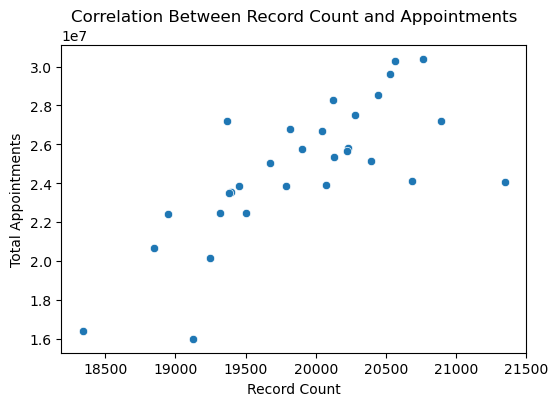

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(6,4))

# Scatterplot
sns.scatterplot(
    data=corr_df,
    x='record_count',
    y='count_of_appointments'
)

# Titles and labels
plt.title('Correlation Between Record Count and Appointments')
plt.xlabel('Record Count')
plt.ylabel('Total Appointments')

# Show plot
plt.show()

**<h3>Visualisation: Correlation between Record Count and Appointments</h3>**
A positive relationship appears to exist between the number of records and the total number of appointments per month, as months with more records generally reported higher appointment volumes. 
However, the correlation is not exact because each record represents aggregated appointment activity rather than individual appointments. Therefore, record count reflects reporting structure, while appointment totals reflect actual healthcare demand.

**<h3>Appointment Period</h3>**
The datasets covered NHS appointments between August 2021 and June 2022. actual_duration data covered December 2021–June 2022, while national_categories provided the broader timeline.

**<h3>Service Settings</h3>**
Within NHS North West London ICB (January–June 2022), General Practice was the dominant service setting (2,104 records), followed by:
* Other: 1,318
* Primary Care Network: 1,272
* Extended Access Provision: 1,090
  
This confirms the central role of General Practice in NHS primary care delivery.

**<h3>Appointment Volumes</h3>**
Appointment demand peaked during:
1. November 2021 – 30.4 million
2. October 2021 – 30.3 million
3. March 2022 – 29.6 million
   
The results indicate sustained pressure on NHS services during autumn 2021 and early 2022.

**<h3>Missed Appointments (DNA)</h3>**
DNA appointments were highest in:
* October 2021 – 1.57 million
* November 2021 – 1.43 million
* September 2021 – 1.32 million
  
Missed appointments increased alongside overall appointment demand, suggesting higher operational pressure during peak periods.

**<h3>Record Volumes and Correlation</h3>**
Monthly record counts remained stable at approximately 18,000–21,000 records per month.
A positive correlation (0.72) was identified between record count and appointment volume, indicating that months with higher reporting activity generally corresponded with increased healthcare demand.

# 4. Visual Analysis – Monthly & Seasonal Trends

### Monthly & Seasonal Trend Analysis

In [42]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(6, 4)})

# Set the plot style as white.
sns.set_style('white')

### Monthly Appointment Patterns

In [43]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = nc['appointment_month'].astype(str)

# Check the data type.
nc.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object

In [44]:
# Aggregate on monthly level and determine the sum of records per month.
monthly_appointments = nc.groupby('appointment_month')['count_of_appointments'].sum()

# View output.
monthly_appointments

appointment_month
2021-08    23852171
2021-09    28522501
2021-10    30303834
2021-11    30405070
2021-12    25140776
2022-01    25635474
2022-02    25355260
2022-03    29595038
2022-04    23913060
2022-05    27495508
2022-06    25828078
Name: count_of_appointments, dtype: int64

**Service settings:**

In [45]:
# Plot the appointments over the available date range, and review the service settings for months.
nc_ss = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View output.
nc_ss.head()

,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843


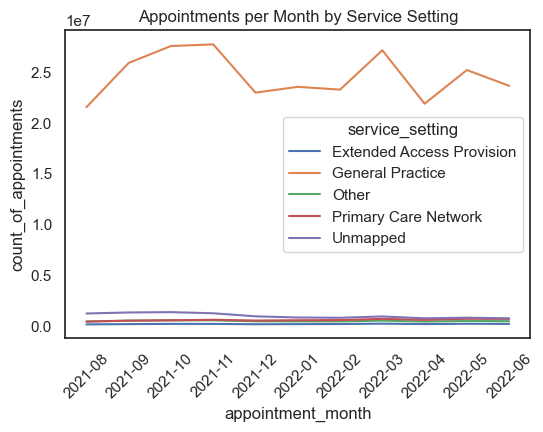

In [46]:
# Create a lineplot.
sns.lineplot(data=nc_ss,
             x='appointment_month',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add title.
plt.title('Appointments per Month by Service Setting')

# Show plot.
plt.show()

**<h3> Visualisation: Appointments per month by Service Setting</h3>**
Main conclusion: General Practice dominates all other service settings.

Trend over time: 
Appointment volumes increased from August 2021, peaked around October–November 2021, March 2022 shows another peak.

Other service settings remained relatively stable.
The scale difference between General Practice and the other service settings makes smaller categories difficult to interpret visually on the same axis.

In [47]:
# Create a separate data set that can be used in future weeks. 
nc_ct = nc.groupby(['appointment_month', 'context_type'])['count_of_appointments'].sum().reset_index()

# View output.
nc_ct.head()

,appointment_month,context_type,count_of_appointments
0,2021-08,Care Related Encounter,20255235
1,2021-08,Inconsistent Mapping,2363093
2,2021-08,Unmapped,1233843
3,2021-09,Care Related Encounter,24404251
4,2021-09,Inconsistent Mapping,2782135


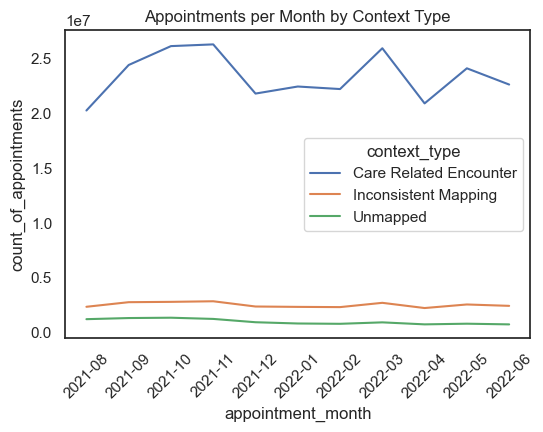

In [48]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
sns.lineplot(data=nc_ct,
             x='appointment_month',
             y='count_of_appointments',
             hue='context_type',
             errorbar=None)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add title.
plt.title('Appointments per Month by Context Type')

# Show plot.
plt.show()

**National categories:**

In [49]:
# Create a separate data set that can be used in future weeks. 
# Create a separate data set for national categories.
nc_nc = nc.groupby(['appointment_month', 'national_category'])['count_of_appointments'].sum().reset_index()

# View output.
nc_nc.head()

,appointment_month,national_category,count_of_appointments
0,2021-08,Care Home Needs Assessment & Personalised Care...,29676
1,2021-08,Care Home Visit,47583
2,2021-08,Clinical Triage,3704207
3,2021-08,General Consultation Acute,4280920
4,2021-08,General Consultation Routine,7756045


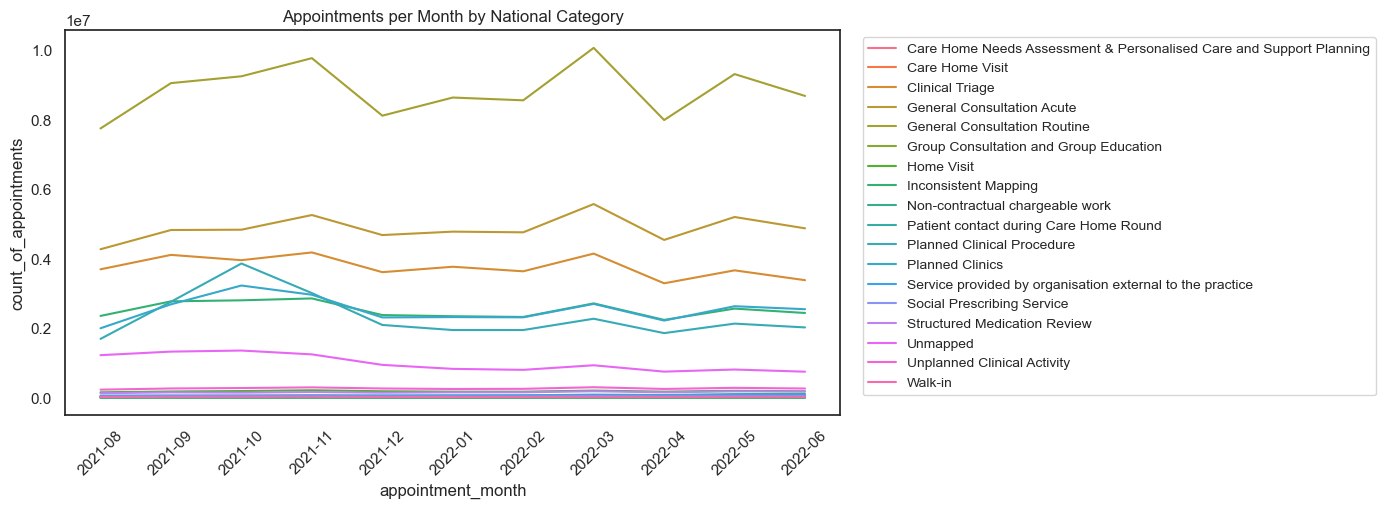

In [50]:
# Plot the appointments over the available date range, and review the national categories for months.

# Set figure size.
sns.set(rc={'figure.figsize':(10, 5)})

# Set the plot style as white.
sns.set_style('white')

# Create a lineplot.
sns.lineplot(data=nc_nc,
             x='appointment_month',
             y='count_of_appointments',
             hue='national_category',
             errorbar=None)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add title.
plt.title('Appointments per Month by National Category')

plt.legend(bbox_to_anchor=(1.02, 1),
           loc='upper left',
           fontsize='small')

# Show plot.
plt.show()

**<h3>Visualisation: Appointments per Month by Context Type</h3>**
Main conclusion: Care Related Encounter CRE)’ overwhelmingly dominates all appointments. 
Trend over time:
CRE rose sharply from August 2021, peaked around October–November 2021, declined afterward,
then showed another increase around March 2022.
“Inconsistent Mapping” and “Unmapped” categories are much smaller, which suggest that:
most appointments were successfully classified, however, some records still contained classification issues. So the graph visually confirms the existence of these data quality limitations.
Although “Inconsistent Mapping” and “Unmapped” categories are relatively small compared with Care Related Encounter appointments, they remain consistently present across all months.

**<h3>Visualisation: Appointments per Month by National Category</h3>**
Main conclusion:
Routine consultations represented the largest proportion of NHS appointments across all months.
The next most common categories appear to be: General Consultation Acute, Clinical Triage and Planned Clinics.
This indicates that:
1. urgent/acute consultations also formed a significant part of NHS workload,
2. triage and planned care services were consistently important.
   
**Temporal trends:**
peaks occur October-November 2021 and March 2022.

Categories such as: Walk-in, Home Visit, Social Prescribing Service, Structured Medication Review,
Care Home Visit show relatively low and stable appointment volumes.
This suggests these services: play more specialised roles, support smaller patient groups.

### Seasonal Appointment Patterns

**Summer (June to August 2021):**

In [51]:
# Create a separate data set that can be used in future weeks. 
seasonal_ss = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View output.
seasonal_ss.head(15)

,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843
5,2021-09,Extended Access Provision,187906
6,2021-09,General Practice,25940821
7,2021-09,Other,527174
8,2021-09,Primary Care Network,530485
9,2021-09,Unmapped,1336115


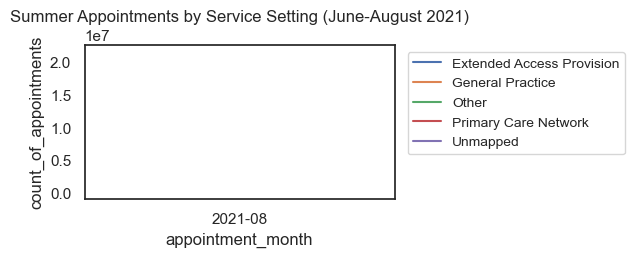

In [52]:
# Look at June to August 2021 in more detail to allow a closer look.
# Create a lineplot.
# Filter the data for June to August 2021.
summer = seasonal_ss[seasonal_ss['appointment_month'].isin(['2021-06',
                                                            '2021-07',
                                                            '2021-08'])]

# Set figure size.
sns.set(rc={'figure.figsize':(4, 2)})

# Set plot style.
sns.set_style('white')

# Create a lineplot.
sns.lineplot(data=summer,
             x='appointment_month',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Add title.
plt.title('Summer Appointments by Service Setting (June-August 2021)')

# Move legend outside the plot.
plt.legend(bbox_to_anchor=(1.02, 1),
           loc='upper left',
           fontsize='small')

# Show plot.
plt.show()

Note: The dataset begins in August 2021; 
therefore, complete summer seasonal analysis was not possible because June and July 2021 data were unavailable.

**Autumn (September to November 2021):**

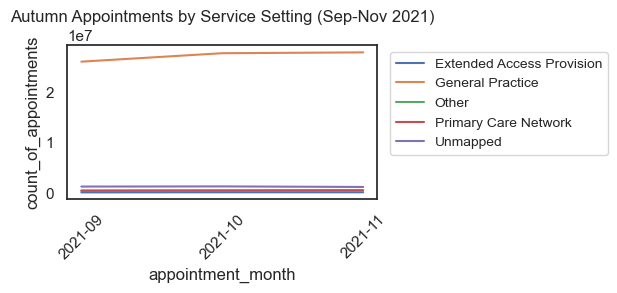

In [53]:
# Look at September to November 2021 in more detail to allow a closer look.
# Create a lineplot.

# Filter the data for September to November 2021.
autumn_2021 = seasonal_ss[seasonal_ss['appointment_month'].isin(['2021-09',
                                                            '2021-10',
                                                            '2021-11'])]

# Create a lineplot.
sns.lineplot(data=autumn_2021,
             x='appointment_month',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add title.
plt.title('Autumn Appointments by Service Setting (Sep-Nov 2021)')

# Move legend outside the plot.
plt.legend(bbox_to_anchor=(1.02, 1),
           loc='upper left',
           fontsize='small')

# Show plot.
plt.show()

**Winter (December to February 2022):**

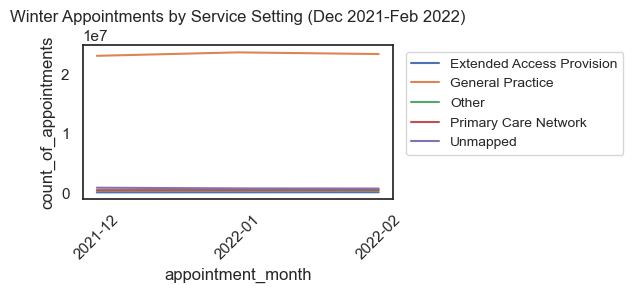

In [54]:
# Look at December to February 2022 in more detail to allow a closer look.
# Filter the data for December 2021 to February 2022.
winter = seasonal_ss[seasonal_ss['appointment_month'].isin(['2021-12',
                                                            '2022-01',
                                                            '2022-02'])]

# Create a lineplot.
sns.lineplot(data=winter,
             x='appointment_month',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add title.
plt.title('Winter Appointments by Service Setting (Dec 2021-Feb 2022)')

# Move legend outside the plot.
plt.legend(bbox_to_anchor=(1.02, 1),
           loc='upper left',
           fontsize='small')

# Show plot.
plt.show()

**Spring (March to May 2022):**

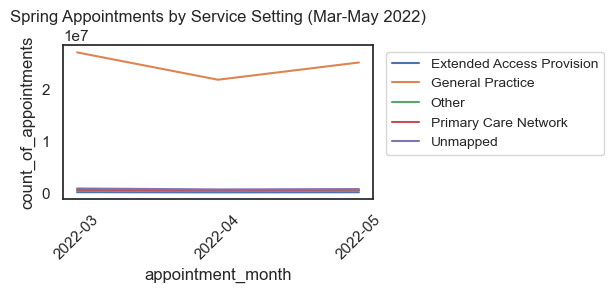

In [55]:
# Look at March to May 2022 in more detail to allow a closer look.
# Filter the data for March to May 2022.
spring = seasonal_ss[seasonal_ss['appointment_month'].isin(['2022-03',
                                                            '2022-04',
                                                            '2022-05'])]

# Create a lineplot.
sns.lineplot(data=spring,
             x='appointment_month',
             y='count_of_appointments',
             hue='service_setting',
             errorbar=None)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add title.
plt.title('Spring Appointments by Service Setting (Mar-May 2022)')

# Move legend outside the plot.
plt.legend(bbox_to_anchor=(1.02, 1),
           loc='upper left',
           fontsize='small')

# Show plot.
plt.show()

**<h3>Overall conclusion:</h3>**
General Practice consistently dominated all seasons.

**Summer 2021:** June and July data are unavailable

**Autumn 2021:** Appointment activity increased and reached its highest levels (October-November 2021) across the observed period.

Other service settings remained relatively stable with only minor fluctuations.

**Winter 2021-2022:** Appointment volumes stabilised slightly below autumn peaks

This suggests:
- sustained healthcare demand during winter,
-  continued pressure on NHS primary care services.
Smaller service settings again showed minimal variation.

**Spring 2022:**
Fluctuations became more noticeable.
A sharp decline in April 2022, followed by recovery in May 2022.

This indicates:
* appointment demand was less stable during spring,
* possible operational or seasonal fluctuations affected service activity.

# 5. Social Media Analysis – Healthcare Conversations

### Healthcare Social Media Analysis

In [56]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(6, 4)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [57]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
tweets.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [58]:
# Explore the metadata.
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB


In [59]:
# Explore the data set.
tweets.describe()

,tweet_id,tweet_retweet_count,tweet_favorite_count
count,1.174000e+03,1174.000000,1174.00000
mean,1.567612e+18,8.629472,0.37138
std,2.427553e+13,29.784675,2.04470
min,1.567574e+18,0.000000,0.00000
25%,1.567590e+18,0.000000,0.00000
50%,1.567611e+18,1.000000,0.00000
75%,1.567633e+18,3.000000,0.00000
max,1.567655e+18,303.000000,42.00000


In [60]:
# Would it be useful to only look at retweeted and favourite tweet messages?
# Analysing these columns can help identify: highly engaging tweets, /
# public interest and sentiment, whether certain healthcare-related topics generate stronger reactions and more.

# View tweet_retweet_count in a clearer table format.
retweet_counts = tweets['tweet_retweet_count'].value_counts().reset_index()

# Rename columns.
retweet_counts.columns = ['retweet_count', 'frequency']

# View output.
retweet_counts

,retweet_count,frequency
0,0,526
1,1,215
2,2,114
3,3,70
4,5,35
5,4,27
6,7,18
7,12,16
8,8,15
9,73,14


In [61]:
# View tweet_favorite_count in a clearer table format.
favorite_counts = tweets['tweet_favorite_count'].value_counts().reset_index()

# Rename columns.
favorite_counts.columns = ['favorite_count', 'frequency']

# View output.
favorite_counts

,favorite_count,frequency
0,0,1027
1,1,91
2,2,16
3,3,13
4,4,7
5,5,5
6,6,2
7,17,1
8,12,1
9,10,1


In [62]:
# Create a new DataFrame containing only the text.
tweets_text = tweets[['tweet_full_text']]

# View the DataFrame.
tweets_text.head()

,tweet_full_text
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."


In [63]:
# Create an empty list.
tags = []

# Use a for loop to extract hashtags.
for y in [x.split(' ') for x in tweets['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Change to lowercase.
            tags.append(z.lower())

In [64]:
# Create a Pandas Series to count hashtag values.
tags = pd.Series(tags).value_counts()

# Display the first 30 records.
tags.head(30)

#healthcare                    716
#health                         80
#medicine                       41
#ai                             40
#job                            38
#medical                        35
#strategy                       30
#pharmaceutical                 28
#digitalhealth                  25
#pharma                         25
#marketing                      25
#medtwitter                     24
#biotech                        24
#competitiveintelligence        24
#meded                          23
#vaccine                        18
#hiring                         18
#news                           17
#machinelearning                17
#technology                     17
#coronavirus                    16
#womeninmedicine                16
#covid                          16
#competitivemarketing           16
#wellness                       15
#healthtech                     15
#doctorofveterinarymedicine     14
#science                        14
#medicare           

In [65]:
# Convert the series to a DataFrame in preparation for visualisation.
data = tags.reset_index()

# Rename the columns.
data.columns = ['tag', 'count']

# View output.
data.head()

,tag,count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38


In [66]:
# Fix the count datatype.
data['count'] = data['count'].astype(int)

# View the result.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tag     1754 non-null   object
 1   count   1754 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 27.5+ KB


In [67]:
# Display records where the count is larger than 10.
top_tags = data[data['count'] > 10]

top_tags.head()

,tag,count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38


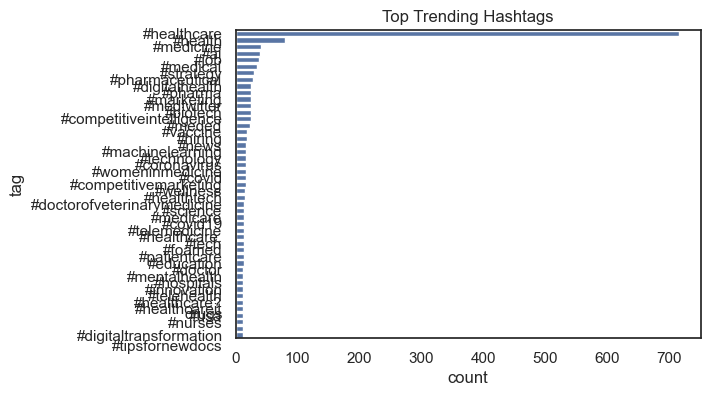

In [68]:
# Create a Seaborn barplot indicating records with a count >10 records.
# Create a barplot.
sns.barplot(data=top_tags,
            x='count',
            y='tag')

# Add title.
plt.title('Top Trending Hashtags')

# Show plot.
plt.show()

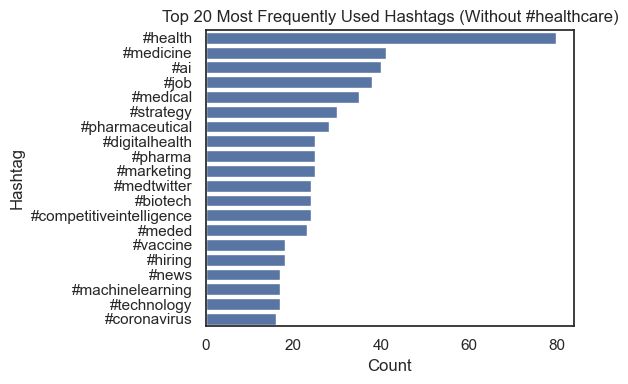

In [69]:
# Remove overrepresented hashtags.
filtered_tags = top_tags[top_tags['tag'] != '#healthcare']

# Keep only the top 20 hashtags.
filtered_tags_top20 = filtered_tags.head(20)

# Create barplot.
sns.barplot(data=filtered_tags_top20,
            x='count',
            y='tag')

# Add title and labels.
plt.title('Top 20 Most Frequently Used Hashtags (Without #healthcare)')
plt.xlabel('Count')
plt.ylabel('Hashtag')

# Improve layout.
plt.tight_layout()

# Show plot.
plt.show()

**<h3>Conclusion 1: Most tweets received very low engagement.</h3>**
The vast majority of tweets received no likes at all: 1,027 tweets had 0 favourites.
Only: 91 tweets received 1 like, very few tweets received more than 2–5 likes.

**<h3>Conclusion 2: Distribution is highly skewed.</h3>**
The engagement metrics are strongly right-skewed:
- most tweets have very low interaction,
- a small number of tweets act as outliers with extremely high engagement.
This suggests that only a small proportion of healthcare tweets attracted significant public attention.

Most variables contain complete data, although: tweet_entities_hashtags contains some missing values (1007 non-null vs 1174 total).
This suggests that not all tweets included structured hashtag metadata. 

**<h3>Hashtag Analysis</h3>**
The hashtag analysis identified several recurring discussion themes, including healthcare, digital technology, recruitment, and pandemic-related topics.
However, the frequency of these hashtags remained relatively low when compared with the scale of NHS appointment activity and healthcare service delivery observed within the operational datasets

Although hashtags such as #ai, #digitalhealth, #job, #hiring, #coronavirus, and #vaccine appeared within the data, their occurrence was not sufficiently large or consistent to establish reliable trends or support evidence-based recommendations for healthcare improvement.

Therefore, the Twitter analysis should be interpreted cautiously. The social media activity represented only a very small proportion of overall healthcare interactions and did not provide a comprehensive reflection of actual NHS demand, operational pressures, or patient behaviour.

# 6. Recommendations – Capacity & Service Improvement

### Operational Recommendations

In [70]:
# Prepare your workstation.
# Load the appointments_regional.csv file.

import pandas as pd
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [71]:
# Convert appointment_month to datetime format.
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# Print the minimum and maximum dates.
print("Minimum date:", ar['appointment_month'].min())
print("Maximum date:", ar['appointment_month'].max())

Minimum date: 2020-01-01 00:00:00
Maximum date: 2022-06-01 00:00:00


In [72]:
# Filter the data set to only look at data from 2021-08 onwards.
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01']

# View the output.
ar_filtered.head()


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E54000034,2021-08-01,Attended,GP,Face-to-Face,1 Day,6553
3653,E54000034,2021-08-01,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E54000034,2021-08-01,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E54000034,2021-08-01,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E54000034,2021-08-01,Attended,GP,Face-to-Face,8 to 14 Days,4961


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [73]:
# Create an aggregated data set to review the different features.
ar_agg = ar_filtered.groupby(
    ['appointment_month',
     'hcp_type',
     'appointment_status',
     'appointment_mode',
     'time_between_book_and_appointment']
)['count_of_appointments'].sum().reset_index()

# View the DataFrame.
ar_agg.head()

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08-01,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08-01,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08-01,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08-01,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08-01,GP,Attended,Face-to-Face,8 to 14 Days,398772


In [74]:
# Filter the data from August 2021 onwards.
ar_filtered = ar[ar['appointment_month'] >= '2021-08-01']

# Determine the total number of appointments per month.
ar_df = ar_filtered.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.
ar_df['utilisation'] = (ar_df['count_of_appointments'] / 30).round(1)

# View the DataFrame.
ar_df.head()

,appointment_month,count_of_appointments,utilisation
0,2021-08-01,23852171,795072.4
1,2021-09-01,28522501,950750.0
2,2021-10-01,30303834,1010127.8
3,2021-11-01,30405070,1013502.3
4,2021-12-01,25140776,838025.9


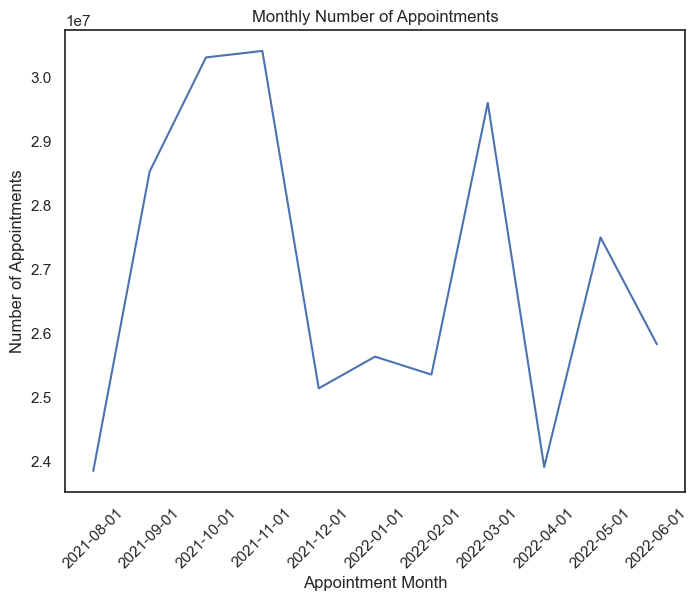

In [75]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_df['appointment_month'] = ar_df['appointment_month'].astype(str)
ar_agg['appointment_month'] = ar_agg['appointment_month'].astype(str)

# Import libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Create a lineplot for monthly appointments.
plt.figure(figsize=(8,6))

sns.lineplot(
    data=ar_df,
    x='appointment_month',
    y='count_of_appointments'
)

plt.xticks(rotation=45)
plt.title('Monthly Number of Appointments')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')

plt.show()

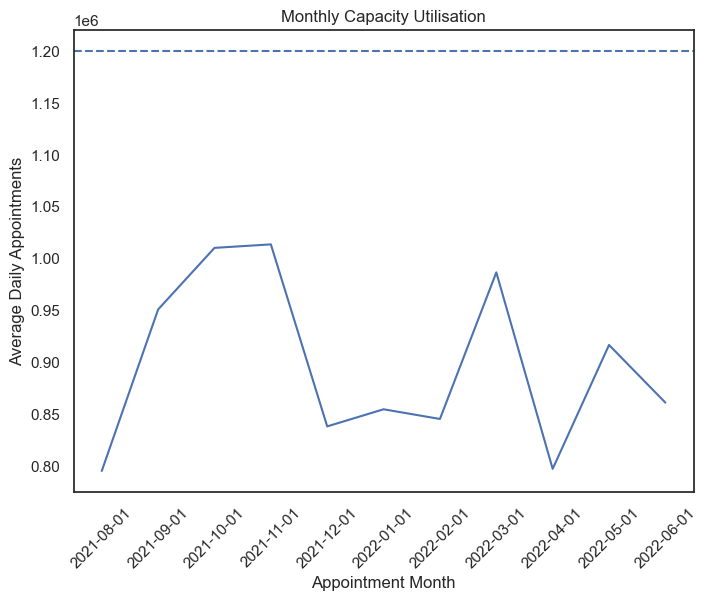

In [76]:
# Plot monthly capacity utilisation.
# Create a lineplot.

plt.figure(figsize=(8,6))

sns.lineplot(
    data=ar_df,
    x='appointment_month',
    y='utilisation'
)

# Add NHS maximum planning capacity line.
plt.axhline(y=1200000, linestyle='--')

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add titles and labels.
plt.title('Monthly Capacity Utilisation')
plt.xlabel('Appointment Month')
plt.ylabel('Average Daily Appointments')

# Display plot.
plt.show()

**Question 2:** How do the healthcare professional types differ over time?

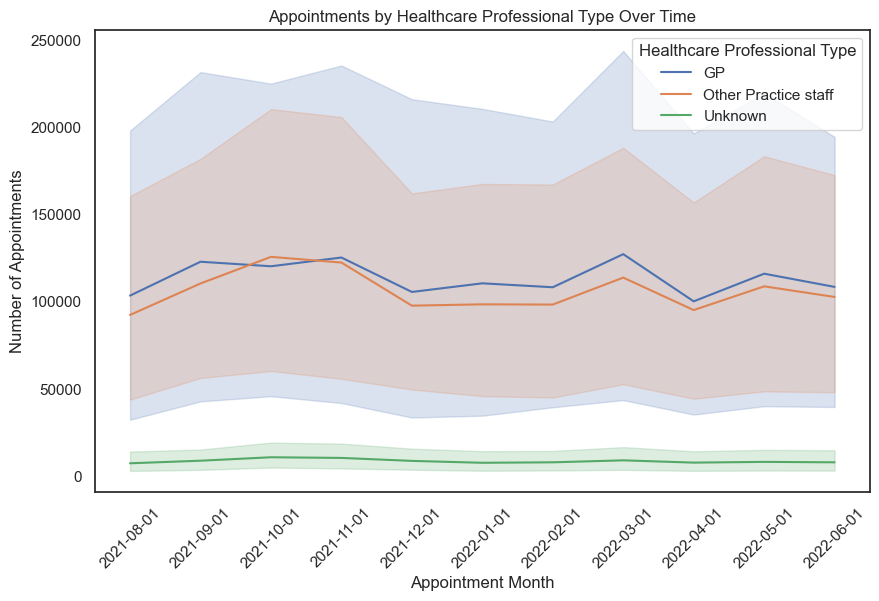

In [77]:
# Create a line plot to answer the question.
plt.figure(figsize=(10,6))

sns.lineplot(
    data=ar_agg,
    x='appointment_month',
    y='count_of_appointments',
    hue='hcp_type'
)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add titles and labels.
plt.title('Appointments by Healthcare Professional Type Over Time')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')

# Display legend.
plt.legend(title='Healthcare Professional Type')

# Display plot.
plt.show() 

**Question 3:** Are there significant changes in whether or not visits are attended?

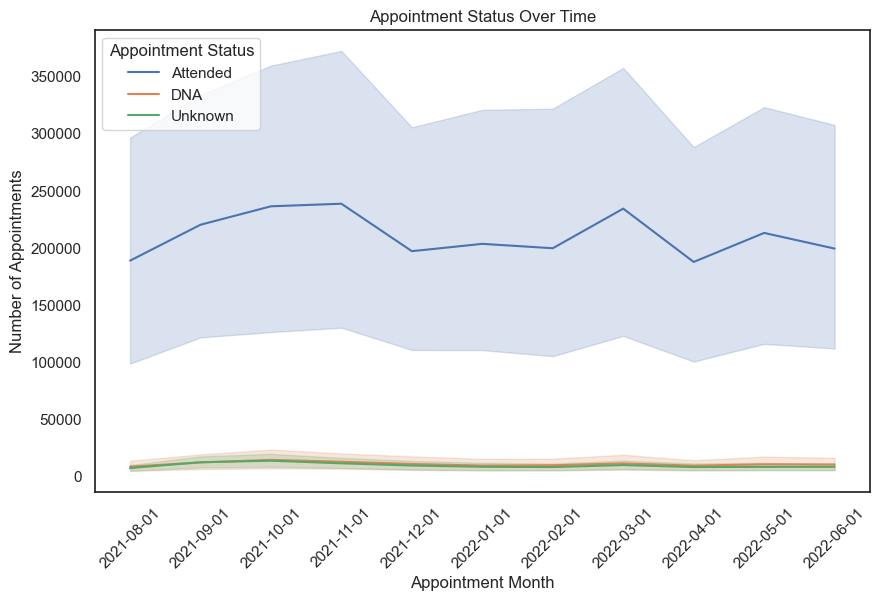

In [78]:
# Create a line plot to answer the question.
plt.figure(figsize=(10,6))

sns.lineplot(
    data=ar_agg,
    x='appointment_month',
    y='count_of_appointments',
    hue='appointment_status'
)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add titles and labels.
plt.title('Appointment Status Over Time')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')

# Display legend.
plt.legend(title='Appointment Status')

# Display plot.
plt.show()

**Question 4:** Are there changes in terms of appointment type and the busiest months?

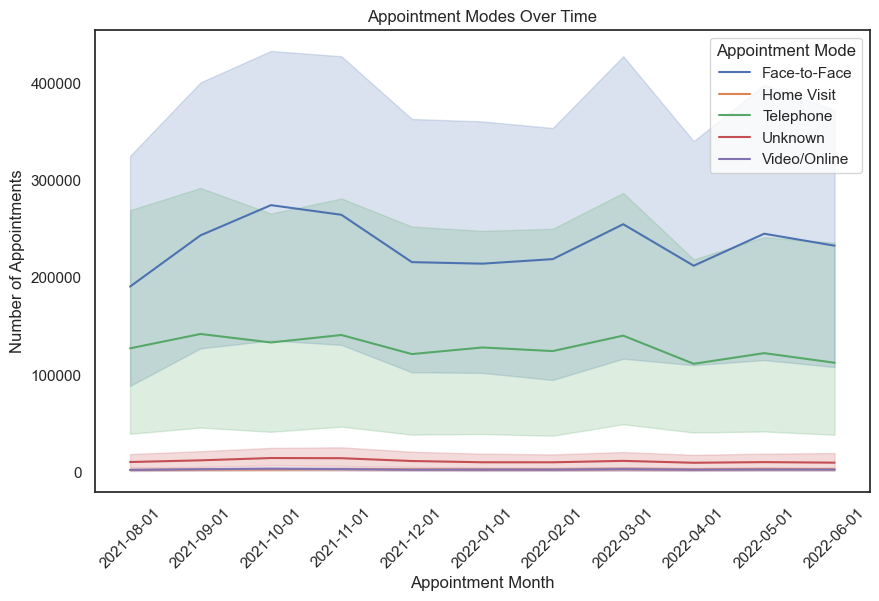

In [79]:
# Create a line plot to answer the question.
plt.figure(figsize=(10,6))

sns.lineplot(
    data=ar_agg,
    x='appointment_month',
    y='count_of_appointments',
    hue='appointment_mode'
)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add titles and labels.
plt.title('Appointment Modes Over Time')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')

# Set the plot style as white.
sns.set_style('white')

# Display legend.
plt.legend(title='Appointment Mode')

# Display plot.
plt.show()

**Question 5:** Are there any trends in time between booking and appointment?

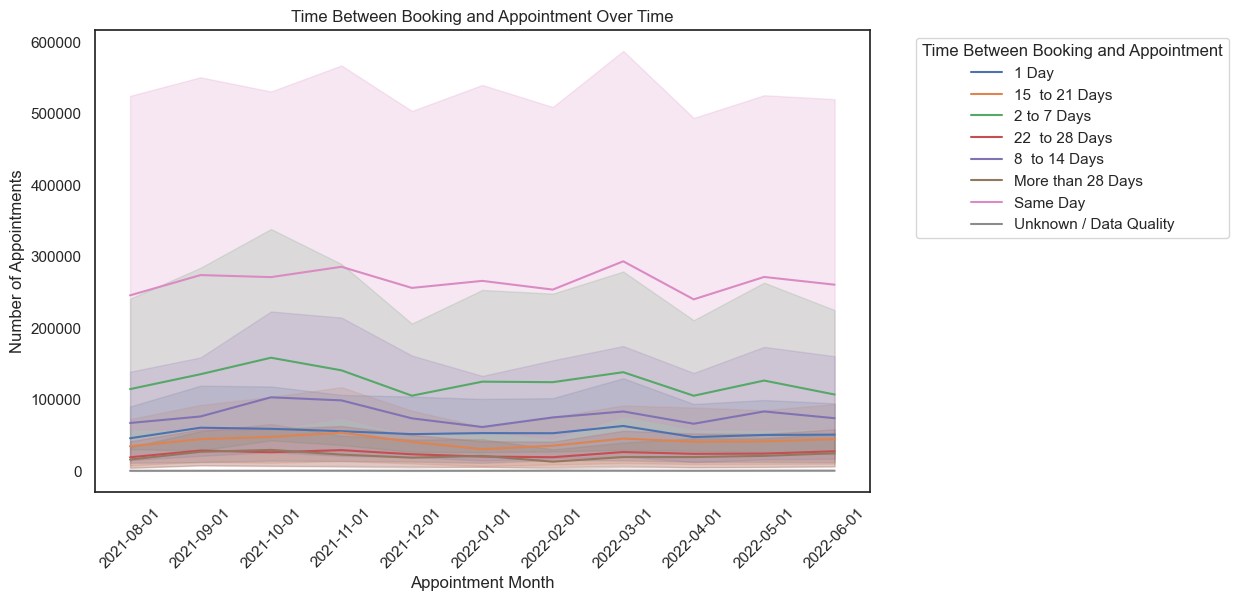

In [80]:
# Create a line plot to answer the question.
plt.figure(figsize=(10,6))

sns.lineplot(
    data=ar_agg,
    x='appointment_month',
    y='count_of_appointments',
    hue='time_between_book_and_appointment'
)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add titles and labels.
plt.title('Time Between Booking and Appointment Over Time')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')

# Display legend.
plt.legend(title='Time Between Booking and Appointment',
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

# Display plot.
plt.show()

**Question 6:** How do the various service settings compare?

In [81]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [82]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
# Create a new aggregated DataFrame.
nc_nc = nc.groupby(
    ['appointment_month', 'national_category']
)['count_of_appointments'].sum().reset_index()

# Convert appointment_month to string for plotting.
nc_nc['appointment_month'] = nc_nc['appointment_month'].astype(str)

# View the DataFrame.
nc_nc.head()

,appointment_month,national_category,count_of_appointments
0,2021-08,Care Home Needs Assessment & Personalised Care and Support Planning,29676
1,2021-08,Care Home Visit,47583
2,2021-08,Clinical Triage,3704207
3,2021-08,General Consultation Acute,4280920
4,2021-08,General Consultation Routine,7756045


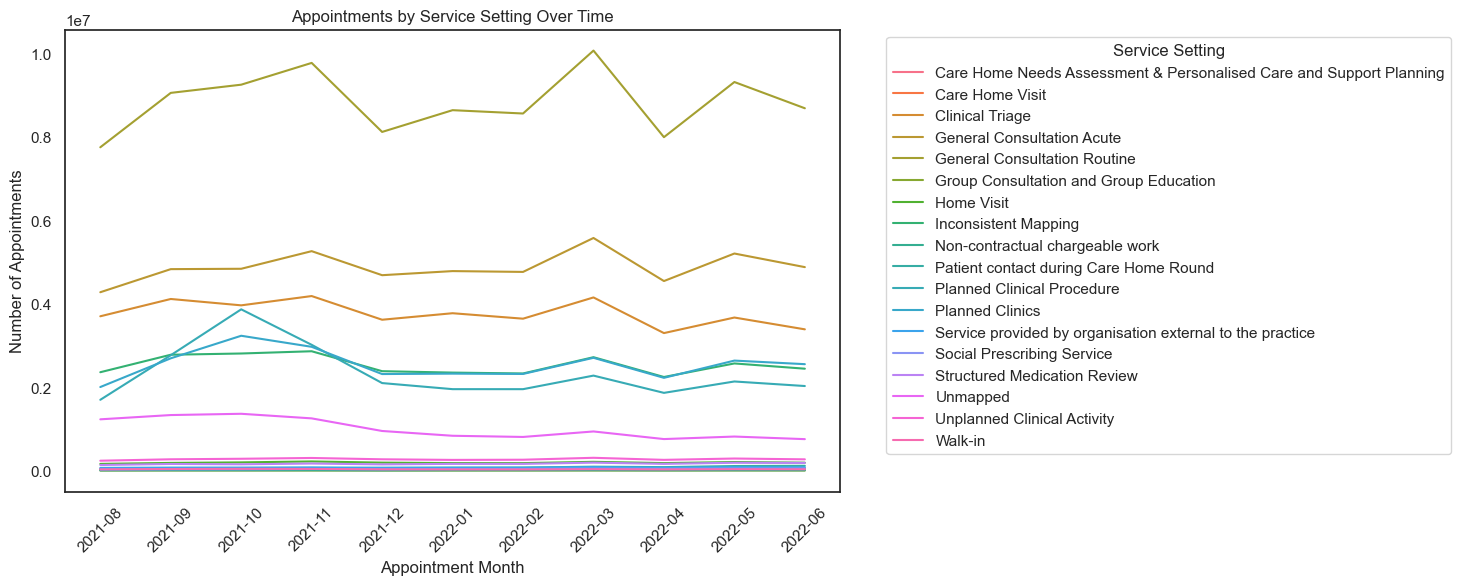

In [83]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
plt.figure(figsize=(10,6))

sns.lineplot(
    data=nc_nc,
    x='appointment_month',
    y='count_of_appointments',
    hue='national_category'
)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add titles and labels.
plt.title('Appointments by Service Setting Over Time')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')

# Display legend.
plt.legend(
    title='Service Setting',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Save visualisation.
plt.savefig('service_settings_all.png', bbox_inches='tight')

# Display plot.
plt.show()

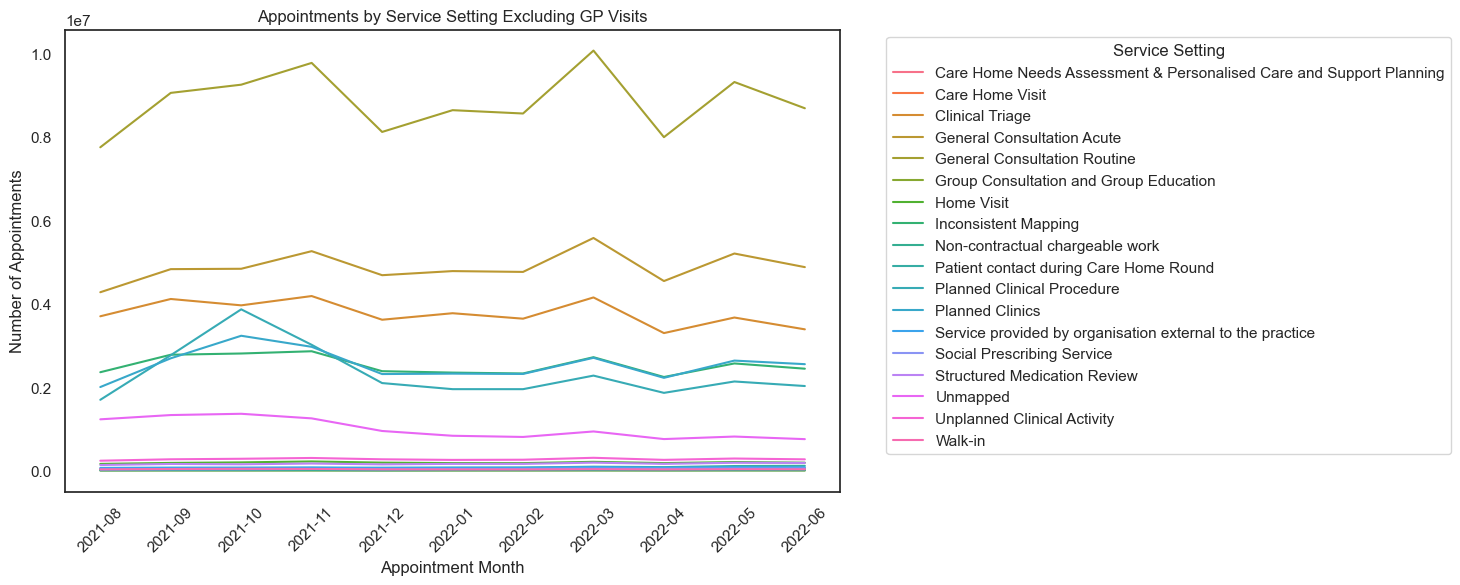

In [84]:
# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding GP visits.
 # Create a DataFrame excluding GP visits.
nc_no_gp = nc_nc[nc_nc['national_category'] != 'GP']

plt.figure(figsize=(10,6))

sns.lineplot(
    data=nc_no_gp,
    x='appointment_month',
    y='count_of_appointments',
    hue='national_category'
)

# Rotate x-axis labels.
plt.xticks(rotation=45)

# Add titles and labels.
plt.title('Appointments by Service Setting Excluding GP Visits')
plt.xlabel('Appointment Month')
plt.ylabel('Number of Appointments')

# Display legend.
plt.legend(
    title='Service Setting',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Save visualisation.
plt.savefig('service_settings_excluding_gp.png', bbox_inches='tight')

# Display plot.
plt.show()

**Question 7:** When did the highest number of missed appointments occur?

In [85]:
# Filter only missed appointments / Did Not Attend.
dna_df = ar_filtered[
    ar_filtered['appointment_status'] == 'DNA'
]

# Group by month and calculate total missed appointments.
dna_monthly = dna_df.groupby(
    'appointment_month'
)['count_of_appointments'].sum().reset_index()

# Sort from highest to lowest.
dna_monthly_sorted = dna_monthly.sort_values(
    by='count_of_appointments',
    ascending=False
)

# View the month with the highest missed appointments.
dna_monthly_sorted.head()

,appointment_month,count_of_appointments
2,2021-10-01,1565624
3,2021-11-01,1428087
1,2021-09-01,1321348
7,2022-03-01,1289888
9,2022-05-01,1199518


**<h3>Question 1: Should the NHS start looking at increasing staff levels?</h3>**

Based on the visualisations and the aggregated monthly appointment data, there is evidence that the NHS should consider reviewing and potentially increasing staff levels, particularly during periods of peak demand. However, the data suggests that the issue may relate more to capacity management and workforce allocation rather than an immediate universal staff shortage.

The utilisation levels did not exceed the maximum capacity threshold shown in the visualisation. This indicates that the NHS was generally able to cope with demand during the analysed period, although with limited spare capacity. Therefore:

the NHS may not require an immediate large-scale staffing increase across all services,
but should consider targeted workforce expansion, improved scheduling, and flexible resource allocation during peak periods.


**<h3>Question 2: How do the healthcare professional types differ over time?</h3>**

GPs were responsible for the highest volume of appointments across all months.
Other Practice Staff also managed a substantial number of appointments, although consistently slightly lower than GPs. Their activity followed a very similar trend pattern to GPs, suggesting that demand affected both groups similarly.
The “Unknown” category represented only a very small proportion of appointments throughout the period.
Several trends can also be observed over time:

Appointment volumes for both GPs and Other Practice Staff increased during autumn 2021, peaking around October–November 2021.
Decline occurred in December 2021 and early 2022, which may reflect seasonal factors such as holiday periods, reduced working days, or changes in patient demand.
Another increase appeared in March 2022, suggesting renewed pressure on healthcare services.
Despite fluctuations, the gap between GPs and Other Practice Staff remained relatively consistent over time, indicating a stable division of workload between professional groups.

**<h3>Question 3: Are there significant changes in whether or not visits are attended?</h3>**
The key insights:

- Attended appointments consistently represented the vast majority of visits, ranging from approximately 190,000 to 240,000 appointments per month.
- DNA (“Did Not Attend”) appointments remained significantly lower, generally ranging between approximately 8,000 and 16,000 appointments.
- The “Unknown” category accounted for the smallest share, remaining below approximately 10,000 appointments throughout the period.
- Both attended and DNA appointments increased during autumn 2021, peaking around October-November 2021, which reflects the rise in overall appointment demand during this period.
- Appointment volumes declined during December 2021 and early 2022, likely due to seasonal factors such as holidays and winter pressures.
Attended appointments increased again around March 2022, reaching approximately 235,000 appointments, before declining slightly afterwards.
- DNA appointments followed a similar pattern to attended appointments, indicating that missed visits tended to increase when total appointment volumes increased.

**<h3>Question 4:  Are there changes in terms of appointment type and the busiest months?</h3>**
The key findings:

- Face-to-Face appointments remained the dominant consultation type throughout the period, ranging from approximately 190,000 to 275,000 appointments per month.
- Telephone appointments were the second most common mode, remaining relatively stable at approximately 110,000–140,000 appointments.
- Home Visit, Video/Online, and Unknown appointment types represented only a small proportion of total appointments.
- Appointment activity increased across most modes during October–November 2021, identifying autumn 2021 as the busiest period in the dataset.
- Face-to-Face appointments peaked in October 2021 at approximately 275,000 appointments.
- Appointment volumes declined during December 2021 and early 2022, likely due to seasonal pressures and holiday periods, before partially recovering in March 2022.


Overall, the analysis indicates that traditional Face-to-Face consultations continued to dominate NHS service delivery, while remote consultation methods played a secondary but stable supporting role.

**<h3>Question 5: Are there any trends in time between booking and appointment?</h3>**
Key takeaways:

Same Day appointments consistently represented the largest share of bookings, averaging approximately 240,000–290,000 appointments per month.
Appointments booked 2–7 days in advance were the second most common category, remaining relatively stable at approximately 100,000–160,000 appointments.
Appointments scheduled more than two weeks ahead remained comparatively low across the period.
Booking activity increased during October–November 2021 and again in March 2022, aligning with peaks in overall appointment demand.
A temporary decline across most booking intervals occurred during December 2021 and early 2022, likely reflecting seasonal and holiday-related pressures.

Overall, the NHS primarily operated on short booking intervals, indicating a strong emphasis on rapid patient access and short-term appointment scheduling.

**<h3>Question 6: How do the various service settings compare?</h3>**
Key findings:

- General Consultation Routine was the dominant service setting throughout the period, accounting for approximately 7.8–10 million appointments per month.
- General Consultation Acute represented the second largest category, with approximately 4.3–5.6 million appointments monthly.
- Clinical Triage and Home Visit services contributed meaningful but significantly lower volumes compared with routine consultations.
- Appointment activity across most service settings peaked during October–November 2021 and again in March 2022, reflecting periods of elevated NHS demand.
- A temporary decline was observed across most categories during December 2021 and early 2022, likely driven by seasonal and operational pressures.
- Smaller service settings, including Structured Medication Review and Social Prescribing Service, remained relatively stable and represented a minor share of overall activity.

Overall, NHS service delivery was heavily concentrated in routine and acute general consultations, while specialised and support services maintained a smaller but stable supporting role.

### Key Findings & Recommendations

**<h3>Recommendation #1:</h3>**
The NHS should prioritise staffing, funding, and operational support within General Practice services, particularly during predictable peak-demand periods.

**<h3>Recommendation #2:</h3>**
The NHS should adopt seasonal workforce and capacity planning models to better allocate staff and resources during predictable high-demand periods.

**<h3>Recommendation #3:</h3>**
Resource allocation and infrastructure investment should be prioritised within top-5 high-demand urban healthcare systems, particularly London ICBs.

**<h3>Recommendation #4:</h3>**
The NHS should strengthen appointment reminder systems, patient communication, and scheduling flexibility to reduce missed appointments and improve operational efficiency.

**<h3>Recommendation #5:</h3>**
Operational planning should primarily rely on internal healthcare datasets rather than limited social media engagement metrics.